---
# <div align="center"> **COSC2793 | Machine Learning** </div>
# <div align="center"> **Assessment 1 - Melbourne Airbnb Listings** <div>
---

# **Introduction**

Online short-term rental platforms like Airbnb give local hosts the opportunity to rent out their rooms or entire properties to travelers. One of the main challenges hosts faces is deciding on the right nightly price. Setting the price too high can discourage potential guests and reduce bookings, while pricing too low may result in lost income. Since pricing is influenced by a range of factors—such as property features, location, available amenities, and host details—machine learning techniques can be used to analyze historical data and suggest a more appropriate and competitive price.

For Assessment 1, our task is to develop a machine learning model, predicting the price of an Airbnb listing in Melbourne based on the given attributes/features of the dataset. The machine learning models are limited from Week 1 – Week 4 of the course (COSC2793 – Computational Machine Learning), and that the workflow of the model must be justified, and documented in this report using data analysis, performance analysis, and/or knowledge from relevant literature.

We are tasked with evaluating at least three different models to determine which one is the MOST APPROPRIATE for this task. It is required that our report contains an explanation for our evaluation framework, including selecting appropriate performance measures for the task, and justification for our choices.


# **Dataset description**

The dataset, given in this assessment, contains the following features:
-	host_is_superhost
-	city
-	country
-	latitude: Uses the World Geodetic System (WGS84) projection for latitude and longitude.
-	longitude: Uses the World Geodetic System (WGS84) projection for latitude and longitude.
-	room_type
-	accommodates: The maximum capacity of the listing.
-	bathrooms: The number of bathrooms of the listing.
-	Bedrooms: The number of bed(s).
-	minimum_nights: Minimum number of night stay for the listing.
-	number_of_reviews: The number of reviews the listing has.
-	review_scores_rating
-	instant_bookable: Whether the guest can automatically book the listing without the host requiring accepting their booking request. An indicator of a commercial listing.
-	calculated_host_listings_count: The number of listings the host has in the current scrape, in the city/region geography.

The train_data.csv has an additional column which is:
-	price: Daily price in local currency (which in this case, is $AUD)


# **Objectives**

- **Primary goal:** The goal is to develop a machine learning model to predict the prices of an Airbnb listing.
- **Data preparation:**
    - Perform EDA, define relationship between features and make assumptions
- **Feature engineering:**
    - Implement feature engineering techniques e.g., feature scaling, one-hot encoding, etc.,
    -
- **Exploring machine learning models:**
    - This is a **supervised machine learning regression** assessment by:
        -  Selecting and rationale Regression models
        - Train multiple models
        - Evaluate with suitable regression metrics
- **Model Evaluation:**
    - Evaluation on models' metrics:
        - $R^2$:
        - RMSE:
        - MSE:
        - MAE:
    - Implement K-fold validation technique, to ensure thorough models assessment
- **Model selection:**
    - Select the model based on the following aspects:

# **Getting started**

In [1]:
# Installing modules and running .venv environment
!cd . # Change into run.sh directory
!bash run.sh # Run the run.sh file, installing key modules

The system cannot find the path specified.
run.sh: line 2: python: command not found
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python in

# **Importing dataset and modules**

In [ ]:
# Importing libraries for the whole report
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats
import warnings
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
import joblib

# Import Ridge, Lasso, ElasticNet, SGDRegressor models
# Base model for comparison will be Linear Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    SGDRegressor,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_predict,
    cross_val_score,
    KFold,
)

In [ ]:
warnings.filterwarnings("ignore")
pd.options.display.max_rows = 4000

# Set a consistent style for plots
sns.set_theme(style="whitegrid")

# Load dataset
raw_train_file_path = "./dataset/airbnb_dataset_raw/train_data.csv"
raw_test_file_path = "./dataset/airbnb_dataset_raw/test_data.csv"

# Load dataframe and view datasets' heads
train_df = pd.read_csv(raw_train_file_path, delimiter=",")
test_df = pd.read_csv(raw_test_file_path, delimiter=",")

train_df.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [2]:
test_df.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Moreland,Australia,-37.766505,144.980736,Private room,2,1.0,1.0,1.0,3,108,87.0,t,1
1,t,Port Phillip,Australia,-37.859755,144.977369,Entire home/apt,3,1.0,1.0,2.0,3,15,94.0,f,17
2,f,Port Phillip,Australia,-37.864530,144.992238,Private room,2,1.0,1.0,2.0,1,63,90.0,f,1
3,f,Darebin,Australia,-37.697294,145.000816,Private room,2,1.0,1.0,1.0,7,159,94.0,f,3
4,f,Melbourne,Australia,-37.810267,144.985920,Private room,2,1.0,1.0,1.0,1,3,93.0,f,1


In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8586 entries, 0 to 8585
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8586 non-null   str    
 1   city                            8586 non-null   str    
 2   country                         8586 non-null   str    
 3   latitude                        8586 non-null   float64
 4   longitude                       8586 non-null   float64
 5   room_type                       8586 non-null   str    
 6   accommodates                    8586 non-null   int64  
 7   bathrooms                       8586 non-null   float64
 8   bedrooms                        8586 non-null   float64
 9   beds                            8586 non-null   float64
 10  price                           8586 non-null   int64  
 11  minimum_nights                  8586 non-null   int64  
 12  number_of_reviews               8586 non-null

In [4]:
train_df.describe()

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,calculated_host_listings_count
count,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000
mean,-37.825074,145.009374,3.559865,1.282320,1.533077,2.036222,139.771372,3.158747,27.946657,94.176101,7.427324
std,0.065145,0.130473,2.225801,0.557906,0.916369,1.544967,123.293376,20.788007,42.409812,8.471527,15.438001
min,-38.224427,144.531993,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,20.000000,1.000000
25%,-37.849202,144.957065,2.000000,1.000000,1.000000,1.000000,71.000000,1.000000,3.000000,92.000000,1.000000
50%,-37.816460,144.977004,3.000000,1.000000,1.000000,2.000000,115.000000,2.000000,11.000000,97.000000,1.000000
75%,-37.802849,145.008316,4.000000,1.500000,2.000000,2.000000,162.750000,3.000000,33.000000,100.000000,5.000000
max,-37.491059,145.760250,16.000000,9.000000,10.000000,18.000000,3000.000000,1000.000000,479.000000,100.000000,98.000000


In [78]:
# Dropping any duplicate rows (duplicate Airbnb listings)
train_df = train_df.drop_duplicates()

# Reset the training data frame
train_df = train_df.reset_index(drop=True)

# Check new data sizes
print(
    f"After removing duplicates, the dataset has {train_df.shape[0]} rows and {train_df.shape[1]} columns"
)

After removing duplicates, the dataset has 8586 rows and 16 columns


- From what we see, we noticed that there are **NO DUPLICATES** or **MISSING VALUES** in the provided dataset
- We can concluded that there are no imbalance in the dataset, and given that we are training **Linear Regression** models, which are:
    - Not able to handle missing values directly
    - And/or throw an error or produce incorrect assumptions of the dataset
    - No bias with duplicated data

# **Exploratory Data Analysis (EDA)**

Training set splits - Columns of numeric data distribution:


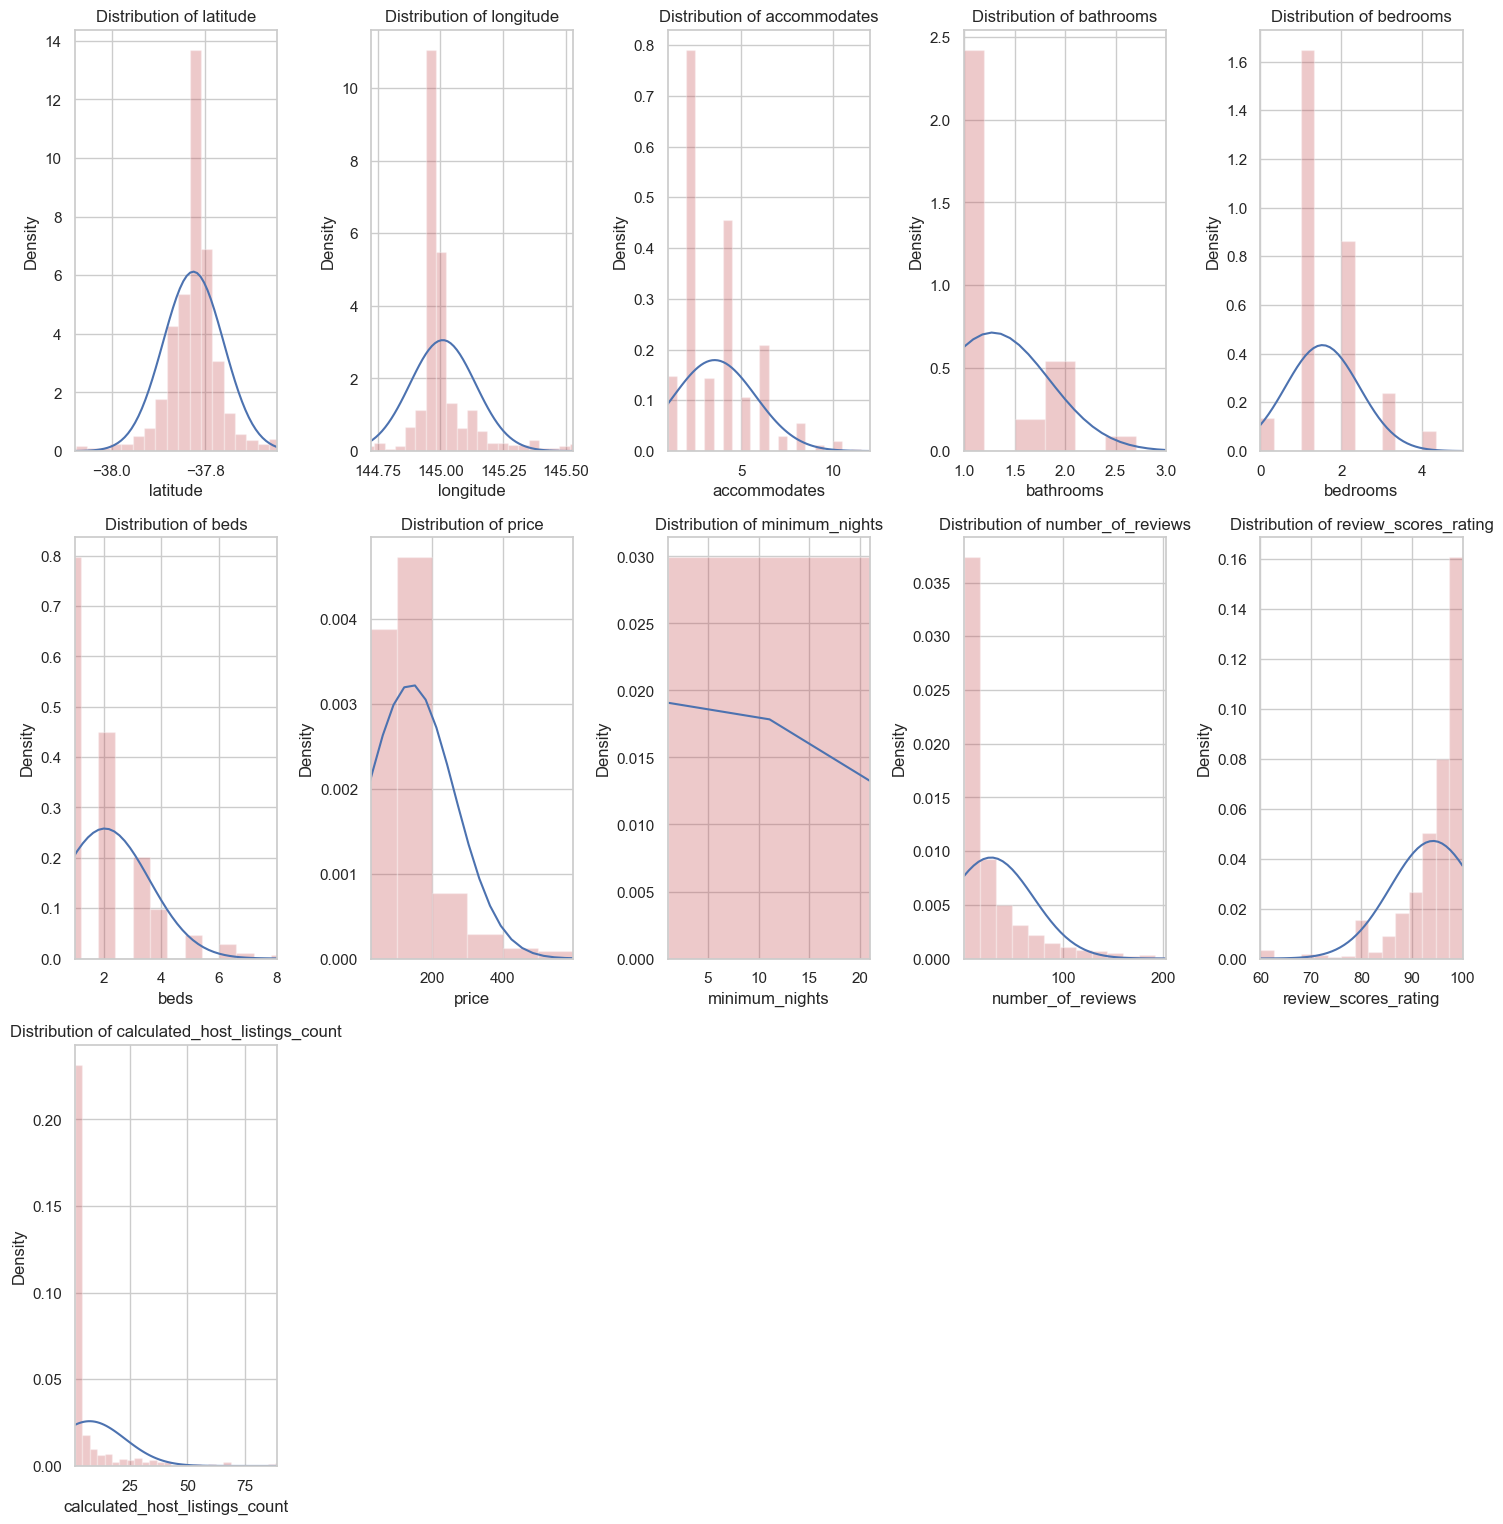

In [ ]:
# Iterate through integer data columns:
numeric_col_df = train_df.select_dtypes(include=['number'])
plt.figure(figsize=(15, 20))

print("Training set splits - Columns of numeric data distribution:")
for i, col in enumerate(numeric_col_df.columns):
    plt.subplot(4, 5, i + 1)

    # Select column data
    data = numeric_col_df[col].dropna()

    plt.hist(data, alpha=0.3, color="r", density=True, bins=30)

    # Calculate mean and std
    mu = data.mean()
    sigma = data.std()

    # Normal distribution curve
    x = np.linspace(data.min(), data.max(), 100)

    # Compute normal distribution
    y = norm.pdf(x, mu, sigma)

    # Plot the normal distribution graph
    plt.plot(x, y)

    # Zoom into 1st-99th percentile
    lower = data.quantile(0.01)
    upper = data.quantile(0.99)
    plt.xlim(lower, upper)

    plt.title("Distribution of " + col)
    plt.ylabel("Density")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

- From what we can see, most features are distributed into Bell Curve shapes, or has a skewed left and/or right distribution. However, for the two columns of price, and minimum_nights, this is indicating the following features: <br>
    **Price:**
    - Needs transformation -> log scaling
    - Otherwise Linear Regression models will perform poorly <br>
    **=> Rationale:** This is because, as linear regression models train on this data, improper scaling of price could lead to wrong assumptions made, and prediction could be off-the-mark. Skewness like this could cause errors to Linear Regression models as outliers (either too large or too small) could lead to it relying/focusing on those data too much.
    Log transformation allow the feature to reduce skewness, compressing larger values into smaller values, and makes distribution more normal.

    **minimum_nights:**
    - Better as a categorical feature
    - Or a grouped feature (e.g., 1 - 3, 4 - 7) <br>
    **=> Rationale:** As for minimum_nights, if we look at it semantically, the values are basically *categorical features*, and **not a numeric relationship**. The effects of this column is non-linear and grouped, although it is numeric data values, grouping minimum_nights can reflect realistic pricing and meaning of this feature.
</br>

- As for categorical features, i.e., **cities**, **room_type**, **host_is_superhost**, and **instant_bookable**, these values can be treated as a categorical features, by using that, we can **classify** Airbnbs, into possible price ranges regarding to their types. For example, a room_type such as a Private home, could have higher price ranges compared to Entire home/apt.

- For the column **country**, this data column can be **removed** as it doesn't provide any additional context, nor any key details to the prediction; since all the Airbnb listed in both the training and testing dataset are defaulted to Australia.

- In terms of **longitude**, and **lattitude**, these two features can be used to provide additional context, and complements each other. Notably, these two features can serve **similarly to the minimum_nights feature**, by providing a price ranges at certain longitude and lattitude measurements, we can classify the prices into groups.

## Checking features correlation

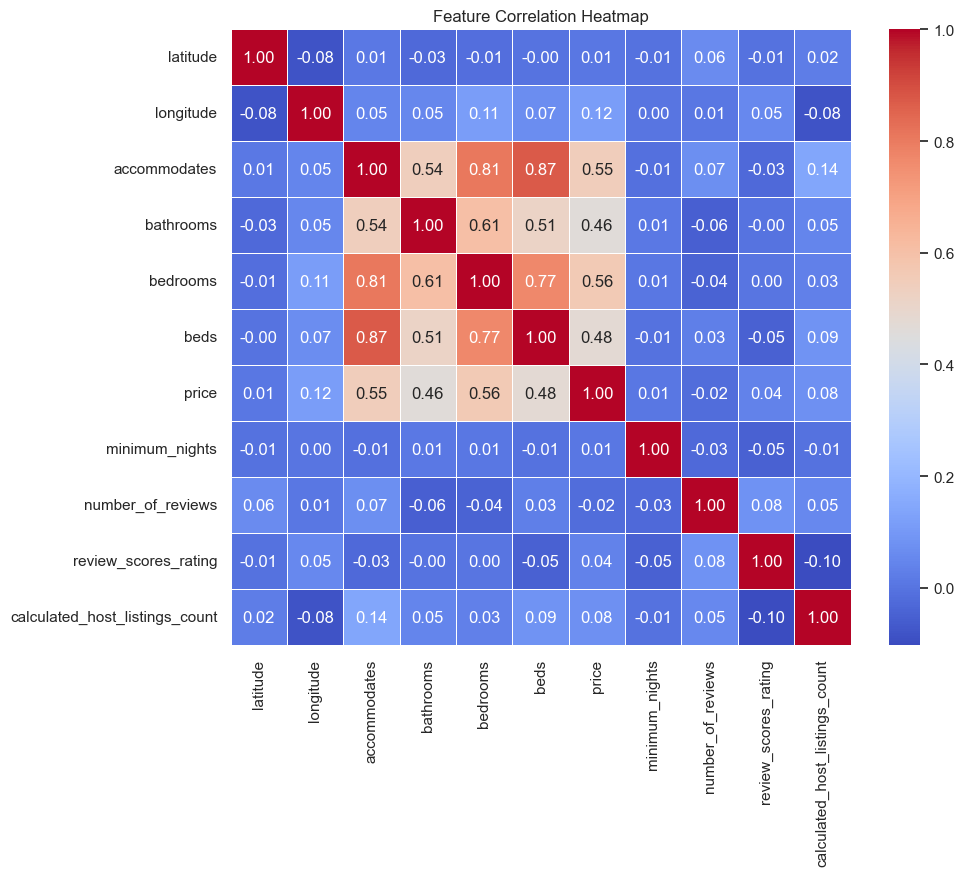

In [7]:
# Load dataset
df = train_df.copy()

# Select only numeric features (correlation only works on numbers)
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,  # Show correlation values
    fmt=".2f",  # Format to 2 decimal places
    cmap="coolwarm",  # Color scheme (blue = low, red = high)
    linewidths=0.5,
)

plt.title("Feature Correlation Heatmap")
plt.show()

**Key Observations:**
- Price are most correlated with the following attributes:
    - `Accommodates, bathrooms, bedrooms and beds` -> has roughly 0.46 - 0.56 correlation score between the two features, showing that the features are strongly correlated <br>
    **Rationale:**
        - These features represent the capacity and size of the property, which directly influences pricing.
        - These are highly informative predictors and should be retained in the model.
        - However, they are also likely correlated with each other (multicollinearity).
    - `Lattitude, Longitude, minimum_nights, review_scores_rating, and calculate_host_listings_count` -> has a weak correlation, at around 0.01 - 0.12 correlation score <br>
    **Rationale:**
        - These features may have:
            - Non-linear relationships with price
            - Interaction effects (e.g., location + property type)
        - And although these features only measures a linear relationship, it does **NOT** imply that the feature has no predictive power.
        - These features are used for further modeling and adding weights rather than being completely removed.
- Also, the correlation graph only captures **linear relationships**, which are sensitive to outliers and skewed distribution. Hence, we can explore more with Scatter plots (for data points and outliers), boxplots (medians, outliders, and interquartile range) and perform feature transformation in order to normalize the dataset scale.
- For categorical data, and see how it correlates with **price** as well as split the training dataset in order to generalizes that model.

<Figure size 1000x800 with 0 Axes>

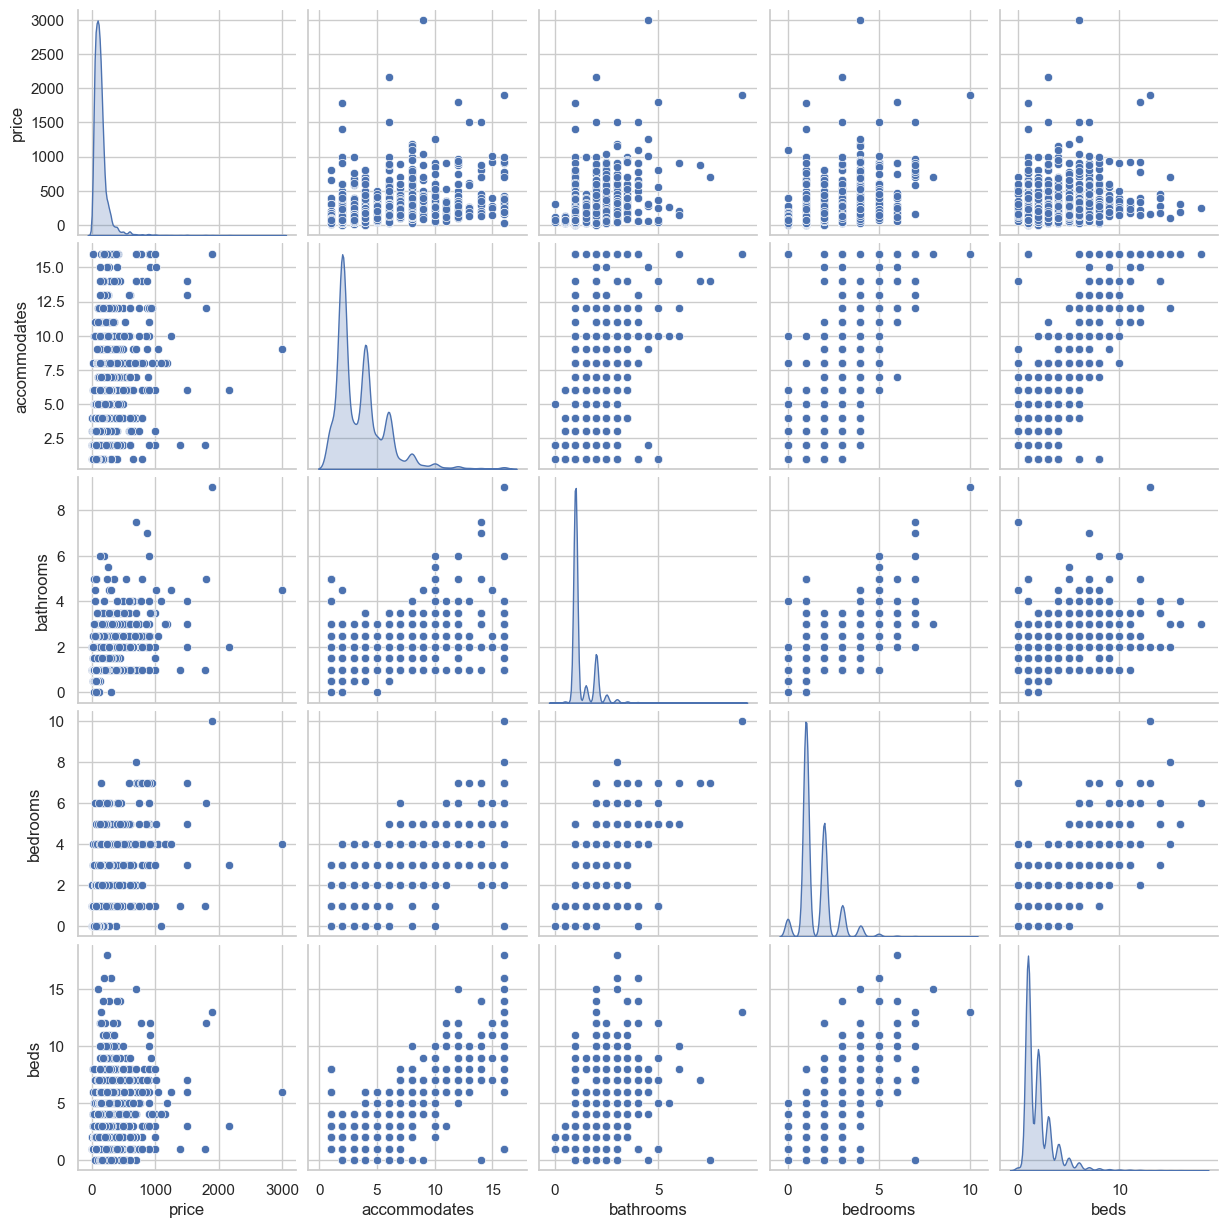

In [8]:
selected_features = ["price", "accommodates", "bathrooms", "bedrooms", "beds"]

plt.figure(figsize=(10, 8))
sns.pairplot(train_df[selected_features], diag_kind="kde")
plt.show()

**Key Observations:**
1. **Skewness in Price Distribution**
The distribution of the target variable (`price`) is highly right-skewed, with most listings concentrated at lower price ranges and a small number of extreme high-value outliers. This indicates that the data does not follow a normal distribution, which can negatively impact linear models. Therefore, a log transformation of the price variable is justified to reduce skewness and stabilize variance.

2. **Positive Relationship Between Price and Accommodates**
There is a clear positive correlation between `price` and `accommodates`. Listings that can host more people generally have higher prices. However, the relationship is not perfectly linear, as there is increasing variability in price for higher accommodation values.

3. **Multicollinearity Among Accommodation Features**
Strong positive relationships are observed between `accommodates`, `bedrooms`, `beds`, and `bathrooms`. These features represent similar underlying characteristics of a listing’s capacity, suggesting redundancy. This multicollinearity can affect the stability of coefficients in linear models, although regularization methods such as Ridge Regression can help mitigate this issue.

4. **Discrete Nature of Features**
The features `bedrooms`, `beds`, and `bathrooms` exhibit discrete patterns, forming grid-like structures in the scatter plots. This is expected, as these variables represent count-based attributes rather than continuous measurements.

5. **Weak Individual Relationships for Some Features**
While `accommodates` shows a relatively strong relationship with price, other features such as `beds` and `bathrooms` display weaker and more dispersed relationships. This suggests that these features may not be strong predictors individually but could still contribute when combined with other variables.

6. **Presence of Heteroscedasticity**
The spread of `price` increases as the value of `accommodates` increases, indicating heteroscedasticity (non-constant variance). This violates one of the assumptions of linear regression and further supports the use of log transformation to stabilize the variance.

7. **Presence of Outliers**
Extreme values are observed in several features, particularly in `price`, as well as in `beds` and `bathrooms`. These outliers may represent rare or luxury listings and can disproportionately influence model training. This justifies the use of outlier handling techniques such as removal or capping.

=> Overall, the pairplot reveals important characteristics of the dataset, including skewness in the target variable, multicollinearity among features, and the presence of outliers. These insights inform subsequent preprocessing steps, including log transformation of the target variable, feature selection, and the use of regularized linear models.

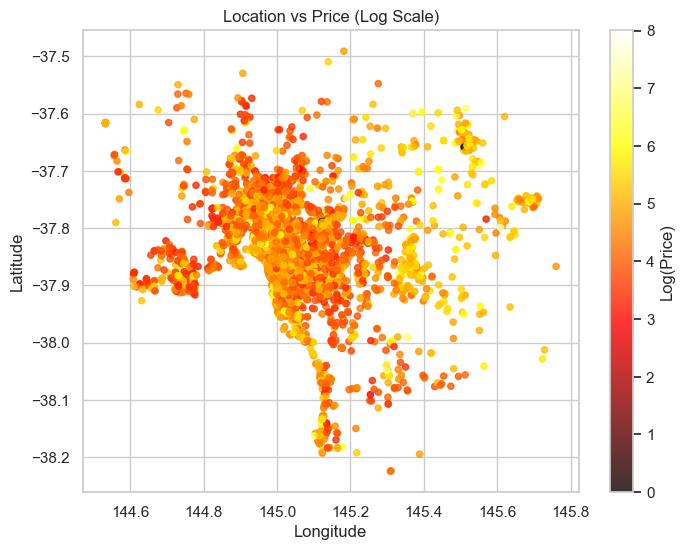

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    train_df["longitude"],
    train_df["latitude"],
    c=np.log1p(train_df["price"]),  # log scale
    cmap="hot",
    alpha=0.8,
    s=20
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Location vs Price (Log Scale)")
plt.colorbar(label="Log(Price)")

plt.show()

**Key Observations:**
- This scatter plot compares the accomodations' locations **via `longitude and lattidue` to logarithmic transformation of `price`**
- The plot shows that the Airbnb listings are concentrated in specific regions/locations areas (e.g., tourist areas, city centre) represented in `Lattitude and Longitude`.
    - The points are represented in clusters, which these clusters are representing high-demand regions<br>
    **Rationale:** This indicates that price is **NOT** randomly distributed, but is affected by spatial location and suggests that the geographic patterns in demand <br>
    Also, although the location features (`lattiude, and longitude`) showed weak correlation from the correlation matrix, this plot reveals a strong **non-linear spatial effects** on price<br>
    This suggests interaction effects between location and structural features, meaning location alone cannot fully explain price variation
- In conclusion, this justifies retaining location-based features and suggests that further feature engineering (e.g., clustering or distance-based features) may improve model performance

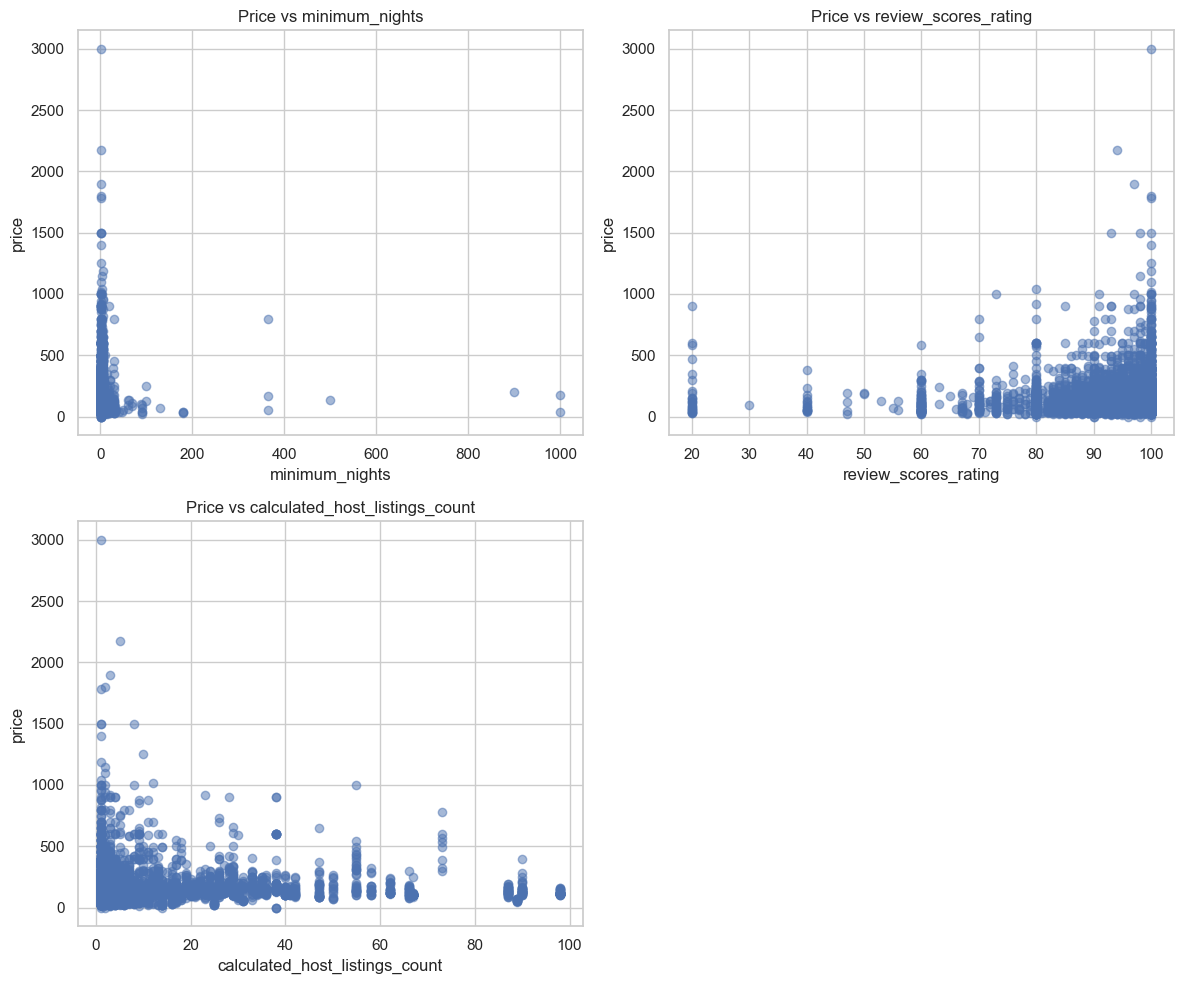

In [10]:
weak_features = [
    "minimum_nights",
    "review_scores_rating",
    "calculated_host_listings_count",
]

plt.figure(figsize=(12, 10))

for i, feature in enumerate(weak_features):
    plt.subplot(2, 2, i + 1)
    plt.scatter(train_df[feature], train_df["price"], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("price")
    plt.title(f"Price vs {feature}")

plt.tight_layout()
plt.show()

**Key Observations:**
- The plots here shows that the three features (`minimum_nights, calculated_host_listings_count, and review_scores_rating`) has an extreme skewed distributrion
- This may caused the model to learn these patterns that are mainly from those regions, hence, when exposed to new unseen data, regions outside of it will have poor predictions from the model
- As linear regression models minimizes the MSE values: $$MSE = \frac{1}{n}\sum(y-y_2)^2$$
    - **Large values produce huge errors when wrong**
- For example, `minimum_nights`, while most values are around 1 - 5, some reaches 100 or even 1000 nights (represented in the plot)
- This calls for **Log Transformation**, in order to compressed large values and small values are preserved, allowing linear regression models to learn the pattern more accordingly

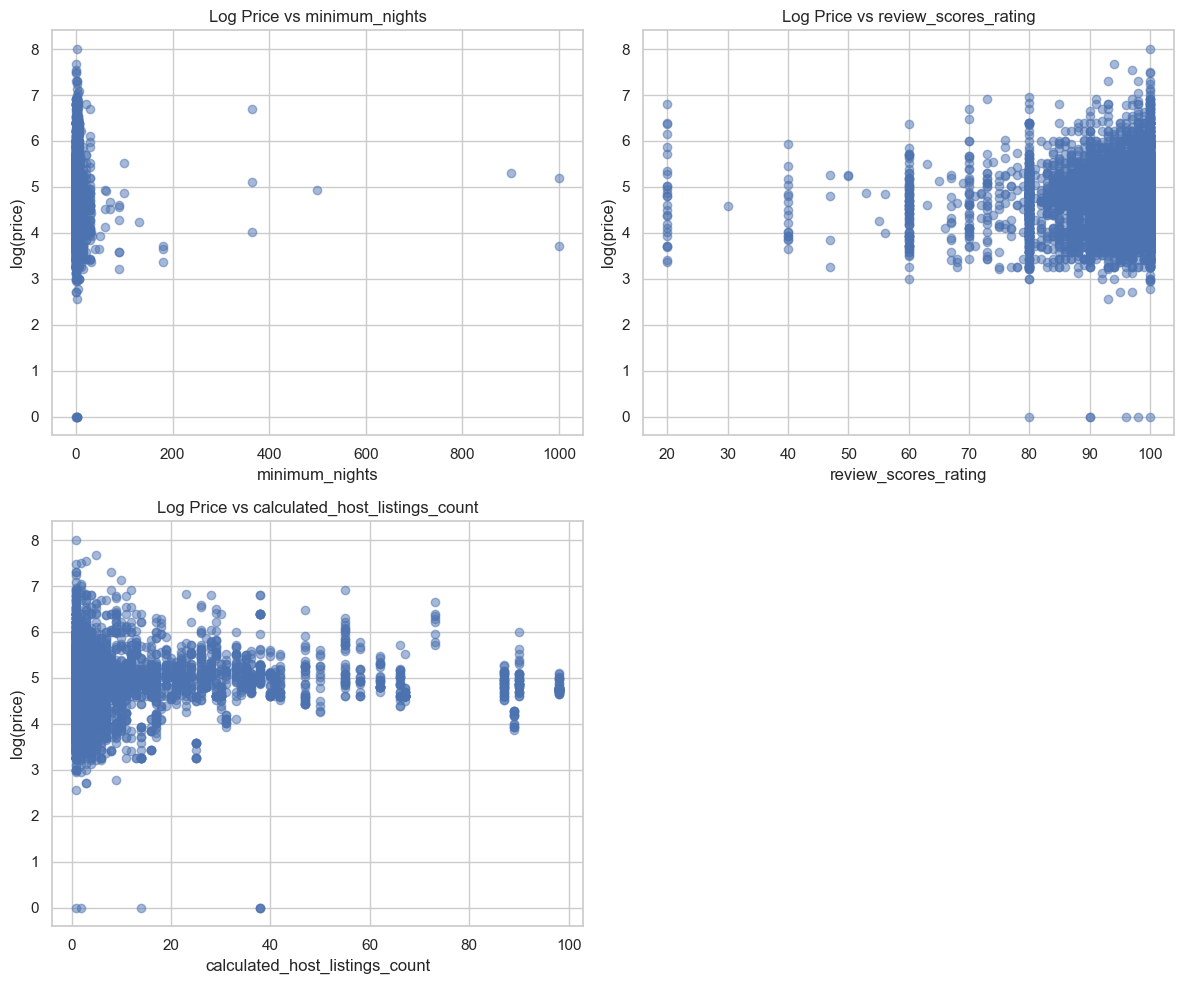

In [11]:
weak_features = [
    "minimum_nights",
    "review_scores_rating",
    "calculated_host_listings_count",
]

plt.figure(figsize=(12, 10))

for i, feature in enumerate(weak_features):
    plt.subplot(2, 2, i + 1)
    plt.scatter(train_df[feature], np.log1p(train_df["price"]), alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("log(price)")
    plt.title(f"Log Price vs {feature}")

plt.tight_layout()
plt.show()

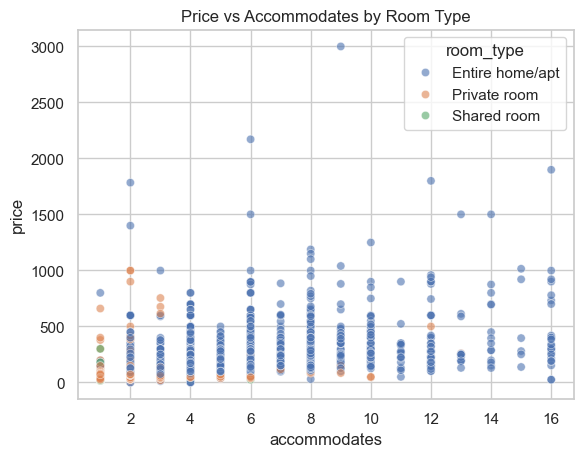

In [ ]:
sns.scatterplot(
    data=train_df,
    x="accommodates",
    y="price",
    hue="room_type",  # categorical feature
    alpha=0.6,
)

plt.title("Price vs Accommodates by Room Type")
plt.show()

**Key Observations:**
- The scatter plot indicates a clear relationship between the `prices` and `accommodates`, where listings that accommodate more guests generally tend to have higher prices
- There are a few outliers (top 10% prices) of these accommodations
- The `accomodates` feature reflects `room_type` and how the room types expected for an appropriate number of accommodates with their respective type. <br>
**Rationale:** The room_type categorical feature indicates that price varies significantly depending on the type of listing:
    - Entire homes/apartments → generally higher prices and higher accommodates
    - Private rooms → moderate prices and accommodates
    - Shared rooms → lowest prices and smallest accommodates <br>
- The plot reveals that accommodates alone does not fully determine `price`, as listings with similar accommodates values exhibit different price ranges depending on their room type.
- For example:
    - Entire homes vs Private room while accommodates = 2: Although both allows 2 guests, entire homes are generally more expensive compared to private rooms

## **Conclusion and features engineering decision**

# **Data splitting and preprocessing**

- First, we want to split the data, and check data's distribution between the dataframes.
- We want to **generalize** the model's predictions on unseen and validate the data first. In order to validate the model's ability to make accurate predictions on unseen data, and we want to tune hyper-parameters, evaluating the model's ability to generalize.
- Since we've made sure there are no duplicated rows in the dataset, we can split the dataset into 3 different splits **training, validation, and testing sets:**
    - **Training:** Train and fit the model and find the **base weights for the model**
    - **Validation:** Further validate and select **optimal weights** that optimizes AI's generalization
    - **Test:** Testing the dataset and unbiased evaluation of the AI model

## Data splitting

The split I have chosen to use is 60/20/20 where:
- Training split fits the model,
- Validation split supports model selection and tuning,
- Holdout split estimates generalization before final submission,
- Provided test_data.csv is used only for final assignment predictions.
    - By performing **k-fold cross validation** is a standard way to estimate the model's generalization more robustly across folds, in order to tune hyperparameters

In [ ]:
# Step 1: Split off test set (20%)
train_split, holdout_split = train_test_split(
    train_df, test_size=0.2, shuffle=True, random_state=42
)

# Step 2: Split remaining 80% into train (60%) and validation (20%)
train_split, val_split = train_test_split(
    train_split, test_size=0.25, shuffle=True, random_state=42
)

print(
    f"Number of instances in the original dataset: {train_df.shape[0]}.\n"
    f"After splitting:\n"
    f"- Train set: {train_split.shape[0]} instances (~60%)\n"
    f"- Validation set: {val_split.shape[0]} instances (~20%)\n"
    f"- Test set: {holdout_split.shape[0]} instances (~20%)"
)

Number of instances in the original dataset: 8586.
After splitting:
- Train set: 5151 instances (~60%)
- Validation set: 1717 instances (~20%)
- Test set: 1718 instances (~20%)


## Data transformation

- Applying a log transformation to the target variable helps stabilize variance, reduce skewness, and ensure that the model focuses on relative rather than absolute errors.
    - This is particularly important in `price` prediction tasks where large values can dominate the loss function.
    - By transforming the target into log space, the model achieves **better generalization** and **more balanced performance** across different price ranges.

In [80]:
# First, modify categorical data columns
# As these features are discrete and influence pricing to the EDA I've performed above
train_df.head()
bool_columns = ["host_is_superhost", "instant_bookable"]

# Then we remove the country data column, as it provides no extra contexts to the data analysis or the column that we are trying to predict
# As the county column contains ONLY 'Australia' as a data type, this feature is redundant to the model's prediction powers
columns_to_drop = ['country', 'price']

# As for price, we keep the price column SEPARATED from the actual dataset first before dropping
y_train = train_split["price"]
y_val = val_split["price"]
y_test = holdout_split["price"]

# Apply numpy log1p function for comparing log transformation
y_train_log = np.log1p(train_split["price"])
y_val_log = np.log1p(val_split["price"])
y_test_log = np.log1p(holdout_split["price"])

# Drop the columns in the List
train_split_cleaned = train_split.drop(columns=columns_to_drop).copy()
val_split_cleaned = val_split.drop(columns=columns_to_drop).copy()
holdout_split_cleaned = holdout_split.drop(columns=columns_to_drop).copy()

# Convert boolean categorical columns to numerical columns (via binary values, 0 and 1)
bool_cols = ["host_is_superhost", "instant_bookable"]

# Convert 't'/'f' to 1/0
train_split_cleaned[bool_cols] = (
    train_split_cleaned[bool_cols].replace({"t": 1, "f": 0}).astype(int)
)
val_split_cleaned[bool_cols] = (
    val_split_cleaned[bool_cols].replace({"t": 1, "f": 0}).astype(int)
)
holdout_split_cleaned[bool_cols] = (
    holdout_split_cleaned[bool_cols].replace({"t": 1, "f": 0}).astype(int)
)

# Apply one-hot encoding for categorical columns
# Fit on training set only
train_split_cleaned = pd.get_dummies(
    train_split_cleaned, columns=["room_type"], drop_first=True
)
val_split_cleaned = pd.get_dummies(
    val_split_cleaned, columns=["room_type"], drop_first=True
)
holdout_split_cleaned = pd.get_dummies(
    holdout_split_cleaned, columns=["room_type"], drop_first=True
)

# Align columns to make sure all sets have the same features
val_split_cleaned = val_split_cleaned.reindex(
    columns=train_split_cleaned.columns, fill_value=0
)
holdout_split_cleaned = holdout_split_cleaned.reindex(
    columns=train_split_cleaned.columns, fill_value=0
)

Grouping `minimum_nights`, and `city` columns into categorical data, and then encoded it like `room_type`, in order to improve model's interpretation of the feature:
- The original `minimum_nights` feature was removed after transformation to avoid **redundancy and multicollinearity**, ensuring the model learns from the grouped categorical representation instead of duplicated information.

In [81]:
# Cleaning up minimum nights, cutting it into groups/bins for easier interpretations
for df in [train_split_cleaned, val_split_cleaned, holdout_split_cleaned]:
    df["minimum_nights_log"] = np.log1p(df["minimum_nights"])

# Build bins from TRAIN only, then apply to val/holdout
_, min_bins = pd.qcut(
    train_split_cleaned["minimum_nights"], q=4, retbins=True, duplicates="drop"
)


def apply_min_nights_bins(df, bins):
    df = df.copy()

    df["minimum_nights_group"] = pd.cut(
        df["minimum_nights"],
        bins=bins,
        labels=["very_low", "low", "medium", "high"][: len(bins) - 1],
        include_lowest=True,
    )

    # Convert to one-hot (numeric)
    dummies = pd.get_dummies(df["minimum_nights_group"], prefix="min_nights")

    df = pd.concat([df, dummies], axis=1)

    # Drop original categorical column
    df = df.drop(columns=["minimum_nights_group"])

    return df


train_split_cleaned = apply_min_nights_bins(train_split_cleaned, min_bins)
val_split_cleaned = apply_min_nights_bins(val_split_cleaned, min_bins)
holdout_split_cleaned = apply_min_nights_bins(holdout_split_cleaned, min_bins)

Perform **One-Hot Encoding** on `city` columns:
- Although one-hot encoding increases dimensionality, it was selected for the `city` feature as it preserves the categorical nature without introducing artificial ordering.
- Given that location is a key determinant of Airbnb pricing, this transformation enables the model to capture location-specific pricing patterns effectively.

In [ ]:
# 1. Keep top 10 most frequent cities in training set
top_cities = train_split_cleaned["city"].value_counts().nlargest(10).index

# 2. Replace rare cities with "Other"
train_split_cleaned["city"] = train_split_cleaned["city"].apply(
    lambda x: x if x in top_cities else "Other"
)
val_split_cleaned["city"] = val_split_cleaned["city"].apply(
    lambda x: x if x in top_cities else "Other"
)
holdout_split_cleaned["city"] = holdout_split_cleaned["city"].apply(
    lambda x: x if x in top_cities else "Other"
)

# 3. One-hot encode city
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

city_encoded_train = encoder.fit_transform(train_split_cleaned[["city"]])
city_encoded_val = encoder.transform(val_split_cleaned[["city"]])
city_encoded_test = encoder.transform(holdout_split_cleaned[["city"]])

# 4. Convert encoded arrays into DataFrames
city_columns = encoder.get_feature_names_out(["city"])

city_train_df = pd.DataFrame(
    city_encoded_train, columns=city_columns, index=train_split_cleaned.index
)

city_val_df = pd.DataFrame(
    city_encoded_val, columns=city_columns, index=val_split_cleaned.index
)

city_test_df = pd.DataFrame(
    city_encoded_test, columns=city_columns, index=holdout_split_cleaned.index
)

# 5. Drop original city column and concatenate encoded columns
train_split_cleaned = pd.concat(
    [train_split_cleaned.drop(columns=["city"]), city_train_df], axis=1
)

val_split_cleaned = pd.concat(
    [val_split_cleaned.drop(columns=["city"]), city_val_df], axis=1
)

holdout_split_cleaned = pd.concat(
    [holdout_split_cleaned.drop(columns=["city"]), city_test_df], axis=1
)

In [37]:
# Check the split
train_split_cleaned.info()

<class 'pandas.DataFrame'>
Index: 5151 entries, 5804 to 2571
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               5151 non-null   int64  
 1   latitude                        5151 non-null   float64
 2   longitude                       5151 non-null   float64
 3   accommodates                    5151 non-null   int64  
 4   bathrooms                       5151 non-null   float64
 5   bedrooms                        5151 non-null   float64
 6   beds                            5151 non-null   float64
 7   minimum_nights                  5151 non-null   int64  
 8   number_of_reviews               5151 non-null   int64  
 9   review_scores_rating            5151 non-null   float64
 10  instant_bookable                5151 non-null   int64  
 11  calculated_host_listings_count  5151 non-null   int64  
 12  room_type_Private room          5151 non-null  

**Adding feature interaction and creating polynomial features:**
- By creating polynomial features, it allows linear regression model to combined features and the assumption of a linear relationship
- The features I have chosen for this feature engineering decision are `accommodates, bedroom, bathrooms`.
    **Rationale:**
    - 

In [ ]:
# Select the columns you want interactions from
interaction_cols = ["accommodates", "bedrooms", "bathrooms"]

# Create polynomial feature generator
polynomial_feat = PolynomialFeatures(
    degree=2, interaction_only=True, include_bias=False
)

# Fit and transform only the selected columns
poly_array = polynomial_feat.fit_transform(train_split_cleaned[interaction_cols])

# Get proper column names
poly_feature_names = polynomial_feat.get_feature_names_out(interaction_cols)

# Convert back to DataFrame
poly_df = pd.DataFrame(
    poly_array, columns=poly_feature_names, index=train_split_cleaned.index
)

# Keep only the new interaction columns
new_interaction_cols = [col for col in poly_df.columns if col not in interaction_cols]

# Add them back to your dataset
train_split_cleaned = pd.concat(
    [train_split_cleaned, poly_df[new_interaction_cols]], axis=1
)

train_split_cleaned.head()

# Transform validation set
poly_val_array = polynomial_feat.transform(val_split_cleaned[interaction_cols])
poly_val_df = pd.DataFrame(
    poly_val_array, columns=poly_feature_names, index=val_split_cleaned.index
)

new_interaction_cols = [
    col for col in poly_val_df.columns if col not in interaction_cols
]

val_split_cleaned = pd.concat(
    [val_split_cleaned, poly_val_df[new_interaction_cols]], axis=1
)

# Transform holdout set
poly_holdout_array = polynomial_feat.transform(holdout_split_cleaned[interaction_cols])
poly_holdout_df = pd.DataFrame(
    poly_holdout_array, columns=poly_feature_names, index=holdout_split_cleaned.index
)

new_interaction_cols = [
    col for col in poly_holdout_df.columns if col not in interaction_cols
]

holdout_split_cleaned = pd.concat(
    [holdout_split_cleaned, poly_holdout_df[new_interaction_cols]], axis=1
)

**Removing outliers:**
- By removing outliers, we are improving the model's ability to generalizes, and make more accurate decisions when predicting a price of an Airbnb
    - Especially since the dataset contains many outliers, such as prices of some instances where it sky-rocketed despite having similar characteristics to other Airbnbs
    - These can be considered external factors such as qualities of Airbnb, Airbnb agencies increasing the price, etc., that cannot be explained by our data alone
- Moreover, we are preventing data leakages, ensuring that the data remains an accurate reflection of real-world data
- Outliers were handled selectively rather than globally across all features. The target variable (price) exhibited strong positive skew, which was addressed using a log transformation to stabilize variance and reduce the impact of extreme values
    - Additionally, extreme outliers in selected numerical features were either removed using the IQR method. This approach preserves data while improving model robustness, particularly for linear models.

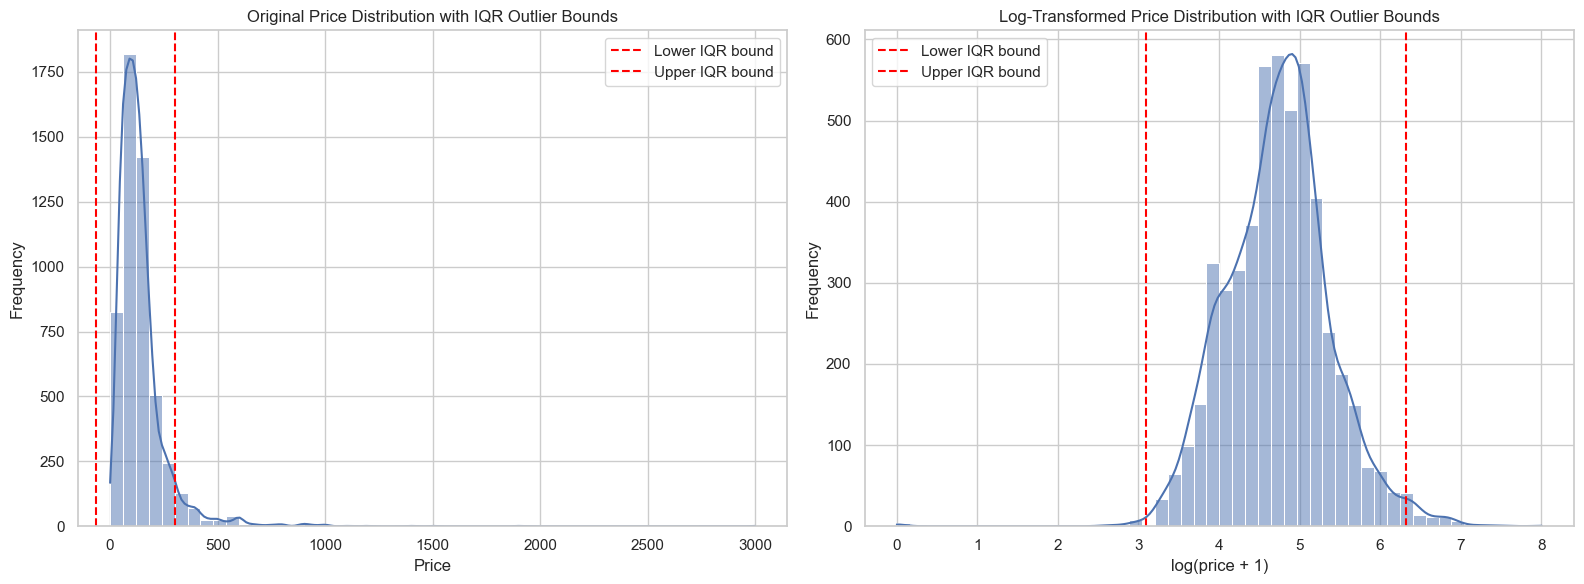

Original price IQR bounds:
Lower bound: -65.00
Upper bound: 303.00

Log-transformed price IQR bounds:
Lower bound: 3.0922
Upper bound: 6.3239


In [84]:
# Select price column from training set only
price = train_split["price"].copy()

# Log transform
price_log = np.log1p(price)

# ----- IQR for original price -----
Q1_price = price.quantile(0.25)
Q3_price = price.quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

# ----- IQR for log-transformed price -----
Q1_log = price_log.quantile(0.25)
Q3_log = price_log.quantile(0.75)
IQR_log = Q3_log - Q1_log

lower_log = Q1_log - 1.5 * IQR_log
upper_log = Q3_log + 1.5 * IQR_log

# ----- Plot both together -----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original price distribution
sns.histplot(price, bins=50, kde=True, ax=axes[0])
axes[0].axvline(lower_price, color="red", linestyle="--", label="Lower IQR bound")
axes[0].axvline(upper_price, color="red", linestyle="--", label="Upper IQR bound")
axes[0].set_title("Original Price Distribution with IQR Outlier Bounds")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Log-transformed price distribution
sns.histplot(price_log, bins=50, kde=True, ax=axes[1])
axes[1].axvline(lower_log, color="red", linestyle="--", label="Lower IQR bound")
axes[1].axvline(upper_log, color="red", linestyle="--", label="Upper IQR bound")
axes[1].set_title("Log-Transformed Price Distribution with IQR Outlier Bounds")
axes[1].set_xlabel("log(price + 1)")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

# Print the thresholds too
print("Original price IQR bounds:")
print(f"Lower bound: {lower_price:.2f}")
print(f"Upper bound: {upper_price:.2f}")

print("\nLog-transformed price IQR bounds:")
print(f"Lower bound: {lower_log:.4f}")
print(f"Upper bound: {upper_log:.4f}")

**Implementing the target transform on all training splits (train, validation, holdout sets)**

In [ ]:
# Removing outliers based on logged transformed target! Matching the scale of the training data
# Target from the SAME training split
price = train_split["price"].copy()
price_log = np.log1p(price)

# IQR on log-transformed target
Q1 = price_log.quantile(0.25)
Q3 = price_log.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Boolean mask: True = keep row
log_outlier_mask = (price_log >= lower) & (price_log <= upper)

# Apply SAME mask to X and y
train_split_cleaned_log = train_split_cleaned.loc[log_outlier_mask].copy()
y_train_log = price_log.loc[log_outlier_mask].copy()

print("Non-filtered X rows:", train_split_cleaned.shape[0])
print("Filtered x rows:", train_split_cleaned_log.shape[0])
print("Filtered y rows:", y_train_log.shape[0])

# Perform the same outliers removal to validation and holdout set using their own targets
price_val_log = np.log1p(val_split["price"])
val_outlier_mask = (price_val_log >= lower) & (price_val_log <= upper)

val_split_cleaned_log = val_split_cleaned.loc[val_outlier_mask].copy()
y_val_log = price_val_log.loc[val_outlier_mask].copy()

price_test_log = np.log1p(holdout_split["price"])
test_outlier_mask = (price_test_log >= lower) & (price_test_log <= upper)

holdout_split_cleaned_log = holdout_split_cleaned.loc[test_outlier_mask].copy()
y_test_log = price_test_log.loc[test_outlier_mask].copy()

Non-filtered X rows: 5151
Filtered x rows: 5059
Filtered y rows: 5059


**Scaling numerical features via StandardScaler:**
- 

In [ ]:
# Scale numerical features using StandardScaler:
numeric_cols = train_split_cleaned.select_dtypes(include=["float64", "int64"]).columns

scaler = StandardScaler()
# Fit ONLY on training data
train_split_cleaned[numeric_cols] = scaler.fit_transform(
    train_split_cleaned[numeric_cols]
)

# Use SAME scaler for validation & test
val_split_cleaned[numeric_cols] = scaler.transform(
    val_split_cleaned[numeric_cols]
)
holdout_split_cleaned[numeric_cols] = scaler.transform(holdout_split_cleaned[numeric_cols])

# Do the same thing for transformed target with standard scaler
scaler_log = StandardScaler()
train_split_cleaned_log[numeric_cols] = scaler_log.fit_transform(
    train_split_cleaned_log[numeric_cols]
)

# Use SAME scaler for validation & test
val_split_cleaned_log[numeric_cols] = scaler_log.transform(
    val_split_cleaned_log[numeric_cols]
)
holdout_split_cleaned_log[numeric_cols] = scaler_log.transform(
    holdout_split_cleaned_log[numeric_cols]
)

train_split_cleaned.head()

,host_is_superhost,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,...,city_Moreland,city_Other,city_Port Phillip,city_Stonnington,city_Whitehorse,city_Yarra,city_Yarra Ranges,accommodates bedrooms,accommodates bathrooms,bedrooms bathrooms
5804,-0.631639,-0.665776,-1.457077,-1.166257,-0.509342,-0.589788,-0.681026,-0.093565,0.859058,-0.138113,...,-0.209715,2.077448,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.619534,-0.680063,-0.454049
5238,-0.631639,-1.352055,0.682308,-1.166257,-1.419690,-0.589788,-0.681026,-0.052749,-0.585228,0.680282,...,-0.209715,2.077448,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.619534,-0.760465,-0.632394
7534,-0.631639,1.102259,-0.121017,0.191550,-0.509342,0.502232,-0.681026,0.151330,-0.561551,0.095714,...,-0.209715,-0.481360,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,0.086131,-0.197655,-0.097361
8374,1.583183,0.196890,-0.362753,0.191550,-0.509342,-0.589788,-0.029230,-0.052749,-0.537874,0.680282,...,-0.209715,-0.481360,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.317106,-0.197655,-0.454049
5249,-0.631639,2.289420,-0.845695,-0.713655,-0.509342,-0.589788,-0.681026,-0.093565,2.918940,-0.371940,...,-0.209715,2.077448,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.518725,-0.519261,-0.454049


**Transforming skewed numeric columns:**
- `number_of_reviews, calculated_host_listings_count` can be transformed in order to transform numeric columns.
- Again, same with a log transformed `price` data feature, log transforming `number_of_reviews, calculated_host_listings_count` allows the model to generalizes and normal distribute the these numeric features.
    - This is better for linear models to learn and understand the relationships between the data features

In [87]:
skewed_count_cols = ["number_of_reviews", "calculated_host_listings_count"]

for df in [train_split_cleaned, val_split_cleaned, holdout_split_cleaned]:
    for col in skewed_count_cols:
        df[f"{col}_log"] = np.log1p(df[col])

train_split_cleaned.head()

,host_is_superhost,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,...,city_Port Phillip,city_Stonnington,city_Whitehorse,city_Yarra,city_Yarra Ranges,accommodates bedrooms,accommodates bathrooms,bedrooms bathrooms,number_of_reviews_log,calculated_host_listings_count_log
5804,-0.631639,-0.665776,-1.457077,-1.166257,-0.509342,-0.589788,-0.681026,-0.093565,0.859058,-0.138113,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.619534,-0.680063,-0.454049,0.620070,-0.427611
5238,-0.631639,-1.352055,0.682308,-1.166257,-1.419690,-0.589788,-0.681026,-0.052749,-0.585228,0.680282,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.619534,-0.760465,-0.632394,-0.880026,-0.531738
7534,-0.631639,1.102259,-0.121017,0.191550,-0.509342,0.502232,-0.681026,0.151330,-0.561551,0.095714,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,0.086131,-0.197655,-0.097361,-0.824512,-0.531738
8374,1.583183,0.196890,-0.362753,0.191550,-0.509342,-0.589788,-0.029230,-0.052749,-0.537874,0.680282,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.317106,-0.197655,-0.454049,-0.771918,0.696236
5249,-0.631639,2.289420,-0.845695,-0.713655,-0.509342,-0.589788,-0.681026,-0.093565,2.918940,-0.371940,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.518725,-0.519261,-0.454049,1.365821,-0.025856


Save the dataset into a new directory, saved as a cleaned training dataset:
- After completing feature engineering and data transformation, the processed datasets were saved into a separate directory to ensure reproducibility and maintain separation from raw data.
- **Additionally**, the fitted StandardScaler and feature column structure were stored to ensure consistent preprocessing during model evaluation and deployment.

In [ ]:
cleaned_train_file_path = "./dataset/airbnb_dataset_cleaned/train_data"

# Saved three cleaned and engineered set into directories as '.csv. format
train_split_cleaned.to_csv(f"{cleaned_train_file_path}/train_cleaned.csv", index=False)
val_split_cleaned.to_csv(
    f"{cleaned_train_file_path}/validation_cleaned.csv", index=False
)
holdout_split_cleaned.to_csv(f"{cleaned_train_file_path}/test_cleaned.csv", index=False)

# Saved StandardScaler for test data/new data being ingested into the model
joblib.dump(scaler, f"{cleaned_train_file_path}/scaler.pkl")

['./dataset/airbnb_dataset_cleaned/train_data/scaler.pkl']

# **Model Selection**

**Model selection rationale:**
- Linear Regression:
    - Base model for comparisons
    - No regularization => Pure model that tests the question "Does regularization help with the model's **predictive power or not**"
- Ridge:
    - This model penalizes large coefficients
    - It reduce chances of overfitting
- Lasso:
    - Can shrink some coefficients to zero -> means the model performs **feature selection**
- ElasticNet:
    - Combines Ridge and Lasso: Allowing stability between the two models
- SGDRegressor:
    - Uses Stochastic Gradient Descent
    - Which is faster when training and for large dataset

**Evaluation framework:**
For this framework, I have decided to use three main evaluation metrics for my regression models, here's my rationale behind selecting each metric, and why it is key to tune hyperparameters of these models:
- RMSE: penalizes large errors more heavily
- MAE: a supporting metric that can measure the typical absolute prediction error in currency units
- $R^2$: shows and explained variance


## Model Train, Predict, and Evaluation

In [99]:
def compare_actual_and_prediction(y_true, y_pred, name, ax):
    ax.scatter(y_true, y_pred, alpha=0.6)

    lims = [
        min(y_true.min(), y_pred.min()),
        max(y_true.max(), y_pred.max()),
    ]

    ax.plot(lims, lims, "k--", alpha=0.75)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")

    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
    ax.set_title(name)

## Model train, predict, and evaluate w/out log transformation

In [63]:
train_split_cleaned.head()

,host_is_superhost,latitude,longitude,accommodates,bathrooms,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,...,city_Port Phillip,city_Stonnington,city_Whitehorse,city_Yarra,city_Yarra Ranges,accommodates bedrooms,accommodates bathrooms,bedrooms bathrooms,number_of_reviews_log,calculated_host_listings_count_log
5804,-0.631639,-0.665776,-1.457077,-1.166257,-0.509342,-0.589788,-0.681026,-0.093565,0.859058,-0.138113,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,0.687844,0.594024,0.300404,0.620070,-0.427611
5238,-0.631639,-1.352055,0.682308,-1.166257,-1.419690,-0.589788,-0.681026,-0.052749,-0.585228,0.680282,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,0.687844,1.655723,0.837316,-0.880026,-0.531738
7534,-0.631639,1.102259,-0.121017,0.191550,-0.509342,0.502232,-0.681026,0.151330,-0.561551,0.095714,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,0.096202,-0.097564,-0.255808,-0.824512,-0.531738
8374,1.583183,0.196890,-0.362753,0.191550,-0.509342,-0.589788,-0.029230,-0.052749,-0.537874,0.680282,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,-0.112974,-0.097564,0.300404,-0.771918,0.696236
5249,-0.631639,2.289420,-0.845695,-0.713655,-0.509342,-0.589788,-0.681026,-0.093565,2.918940,-0.371940,...,-0.365831,-0.279807,-0.157704,-0.329328,-0.203587,0.420905,0.363494,0.300404,1.365821,-0.025856


,MSE,RMSE,MAE,R2
SGD,7047.976656,83.952228,44.743349,0.468318
Ridge,7154.028293,84.581489,45.104338,0.460318
Linear Regression,7155.319020,84.589119,45.111578,0.460221
Lasso,7174.295762,84.701215,44.918252,0.458789
ElasticNet,7358.971237,85.784446,47.288836,0.444858


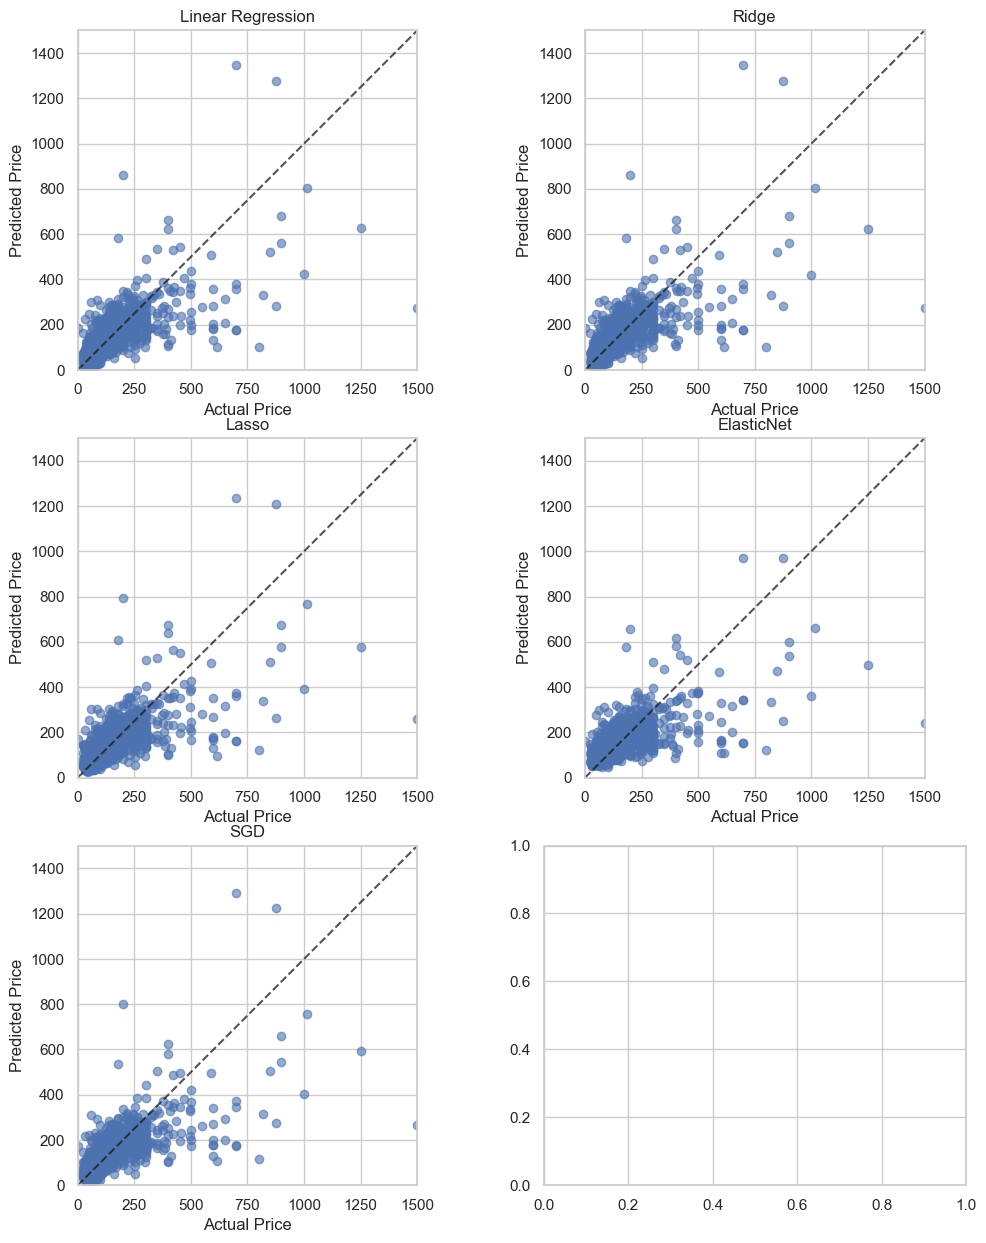

In [ ]:
import math

# Choosen models list:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(),
    "SGD": SGDRegressor(),
}

num_models = len(models)
cols = 2
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten()

results = {}

# Loop to train, predict and evaluate models with key peformance metrics
# for name, model in models.items():
#     # Train
#     model.fit(train_split_cleaned, y_train)

#     # Predict in log space (as the model is trained with y_train in log space)
#     y_pred = model.predict(val_split_cleaned)

#     # Evaluate
#     mse = mean_squared_error(y_val, y_pred)
#     mae = mean_absolute_error(y_val, y_pred)
#     rmse = float(np.sqrt(mse))
#     r2 = r2_score(y_val, y_pred)

#     # Store results
#     results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
#     compare_actual_and_prediction(y_val, y_pred, name, axes[i])

for i, (name, model) in enumerate(models.items()):
    # Train
    model.fit(train_split_cleaned, y_train)

    # Predict
    y_pred = model.predict(val_split_cleaned)

    # Evaluate
    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_val, y_pred)

    results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}

    # Plot on corresponding subplot
    compare_actual_and_prediction(y_val, y_pred, name, axes[i])

# Print
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df

## Model train, predict, and evaluate w/log transformation on target variables

,MSE,RMSE,MAE,R2
Ridge,2968.542616,54.484334,33.186565,0.520904
Linear Regression,2968.899504,54.487609,33.185854,0.520846
SGD,2993.940618,54.716913,33.475293,0.516805
Lasso,6469.664732,80.434226,55.770301,-0.044146
ElasticNet,6469.664732,80.434226,55.770301,-0.044146


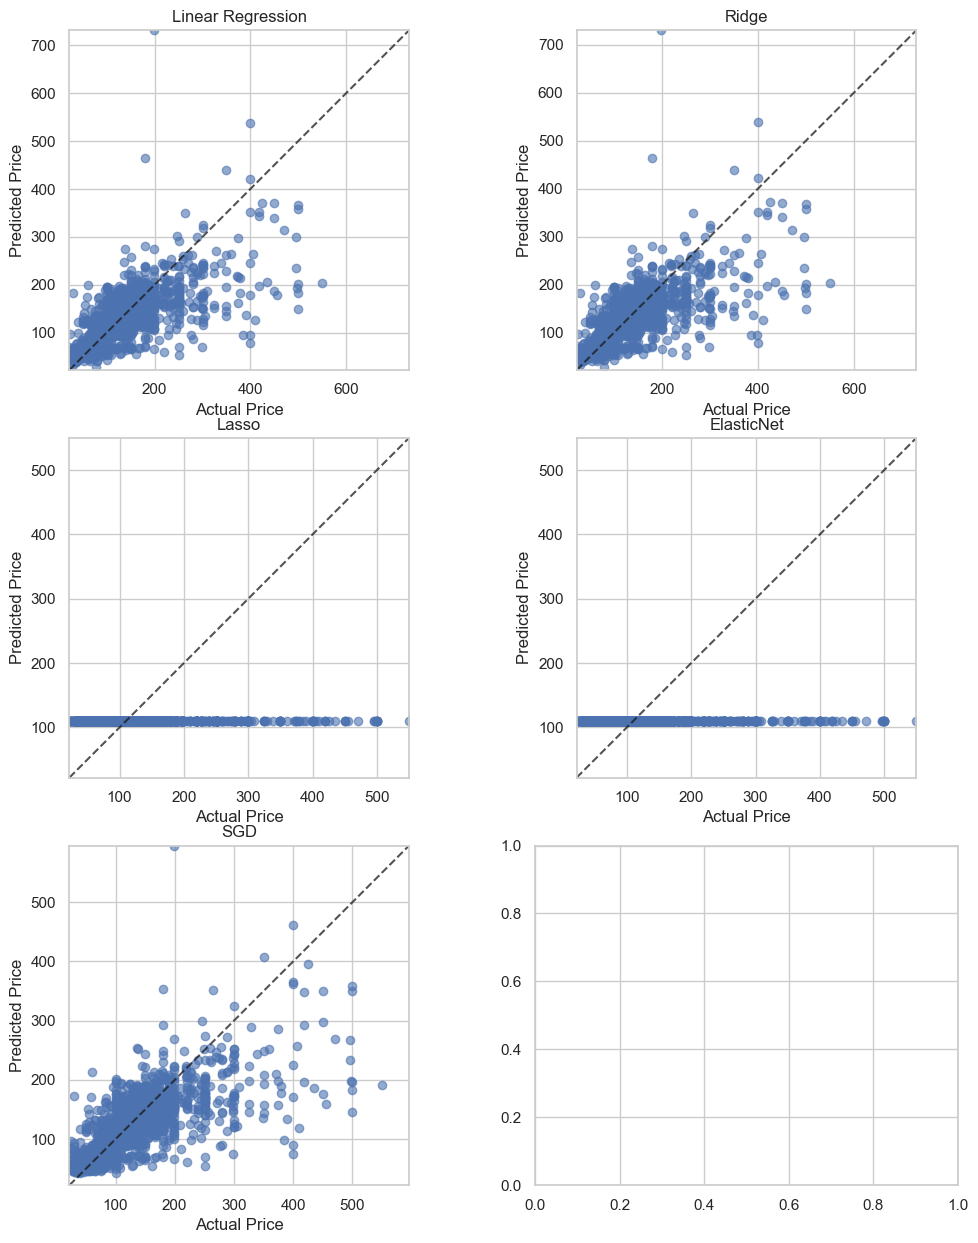

In [104]:
# Choosen models list:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "ElasticNet": ElasticNet(),
    "SGD": SGDRegressor(),
}

num_models = len(models)
cols = 2
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten()

results = {}

# Loop to train, predict and evaluate models with key peformance metrics
for i, (name, model) in enumerate(models.items()):
    # Train
    model.fit(train_split_cleaned_log, y_train_log)

    # Predict in log space (as the model is trained with y_train in log space)
    y_pred_log = model.predict(val_split_cleaned_log)

    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_val_log)

    # Evaluate
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)

    # Store results
    results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
    compare_actual_and_prediction(y_true, y_pred, name, axes[i])

# Print
results_df = pd.DataFrame(results).T.sort_values("RMSE")
results_df

## Comparisons between w/Log transform vs no Log transform

**Key observations:**
- **MAE value decreased** across the models:
    - For LinearRegression, Ridge, and SGD model, the evaluation metrics showed that MAE decreases significantly across the board
    - The log transformation reduced the mean absolute error (MAE) significantly across models, *indicating improved average prediction accuracy*
- The scatter plots reveal that all linear models suffer from underfitting when trained under **raw `price` data feature**
    - 
- However, when the `price` column is transformed, the performance shows significant improvements across-the-board
    - 

**Rationale:**
- The log transformation improves prediction accuracy for most models that I have chosen. Particularly, SGD, LinearRegression (baseline model) and RidgeRegression.
- 

## Model to explore

- The model I have chosen to explore is **Ridge** Regression model. This is because performance wise, Ridge provides the best performance metrics compared to the other models, both when trained with normal prices and when price is log transformed.
- While the Lasso and ElasticNet Regression models failed at predicting price when log transformed, SGD and Linear Regression was able to produce similar results to Ridge. However, the reason why I didn't either of the two is because of the following reasons:
    - Although Linear Regression performs similarly to Ridge Regression, Ridge Regression for hyper-parameter tuning is much more flexible compared to Linear Regression. In contrast, Ridge Regression introduces a regularisation parameter ($\alpha$), which allows control over the trade-off between model complexity and generalisation.This makes Ridge more suitable for fulfilling the assignment requirement of analysing the impact of at least one hyperparameter.
    - While SGD shows promising $MAE$ results after the price was log transformed, however, SGD is highly sensitive to hyper-parameters such as learning rate, iteration count, and feature scaling. This introduces additional complexity and instability to the data pipeline.
- Overall, Ridge Regression provides the best balance between predictive performance, model stability, and analytical depth. Its ability to incorporate regularisation while maintaining strong performance makes it the most appropriate choice for further hyperparameter tuning and evaluation.

# **Model Hyper-parameter Tuning**

- Our goal for this section of the Notebook is to find the 'correct' hyper-parameters, and perform K-fold Cross validation in order to perform the following tasks:
    - Minimizing error performance metrics - metrics such as MSE/RMSE or MAE
    - Improve the model's ability to generalize - Reducing $R^2$ score on unseen data

In [ ]:
# Initialize K-Fold Cross Validation variable, determine 5 splits, and shuffle between data
cv = KFold(n_splits=5, shuffle=True, random_state=42)

## Performing grid search to find the best $\alpha$ hyper-parameter

**Ridge Hyperparameters Tuning:**
- 

Best alpha: {'alpha': np.float64(1.0)}
Best CV RMSE: 0.3456447703691029
Tuned Ridge validation metrics:
MSE  : 2968.54262
RMSE : 54.48433
MAE  : 33.18657
R2   : 0.52090


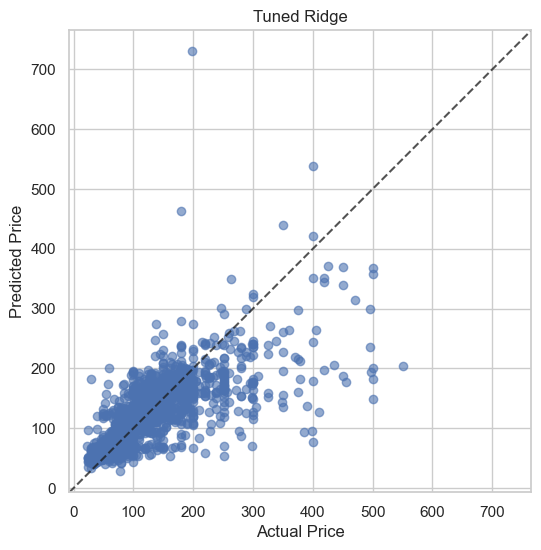

In [95]:
param_grid = {"alpha": np.logspace(-3, 3, 13)}
ridge = Ridge(random_state=42)

grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

grid.fit(train_split_cleaned_log, y_train_log)

best_model = grid.best_estimator_

print("Best alpha:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

# Predict on validation set (log scale)
y_pred_log = best_model.predict(val_split_cleaned_log)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_val_log)

# Evaluate on original price scale
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("Tuned Ridge validation metrics:")
print(f"MSE  : {mse:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"MAE  : {mae:.5f}")
print(f"R2   : {r2:.5f}")

compare_actual_and_prediction(y_true, y_pred, "Tuned Ridge")

In [ ]:
# Custom RMSE scorer on ORIGINAL price scale
def rmse_original(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true, y_pred))


# Convert to sklearn scorer (negative because GridSearch maximizes)
rmse_scorer = make_scorer(rmse_original, greater_is_better=False)

Best alpha: {'alpha': np.float64(0.001)}
Best CV RMSE: 56.918979100837575
Tuned Ridge validation metrics:
MSE  : 2968.89912
RMSE : 54.48761
MAE  : 33.18585
R2   : 0.52085


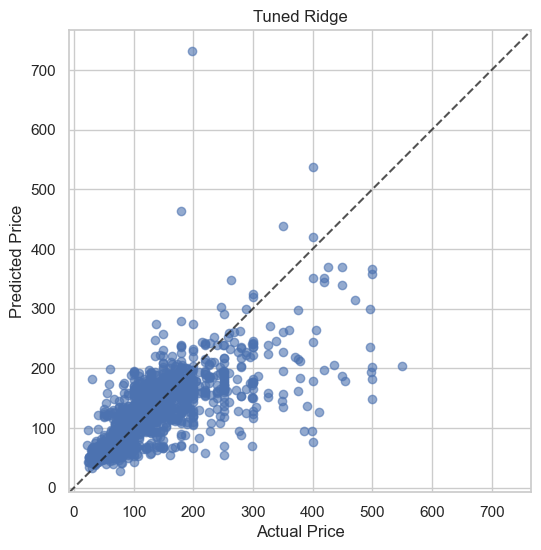

In [97]:
param_grid = {"alpha": np.logspace(-3, 3, 13)}
ridge = Ridge(random_state=42)

grid = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=cv,
    scoring=rmse_scorer,
    n_jobs=-1,
)

grid.fit(train_split_cleaned_log, y_train_log)

best_model = grid.best_estimator_

print("Best alpha:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

# Predict on validation set (log scale)
y_pred_log = best_model.predict(val_split_cleaned_log)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_val_log)

# Evaluate on original price scale
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("Tuned Ridge validation metrics:")
print(f"MSE  : {mse:.5f}")
print(f"RMSE : {rmse:.5f}")
print(f"MAE  : {mae:.5f}")
print(f"R2   : {r2:.5f}")

compare_actual_and_prediction(y_true, y_pred, "Tuned Ridge")

## Limitations with the Assignment 1:
- 

## Ethical considerations and Professional responsibilities:
- 

# **Predicting the price for the test set - Full pipeline**